# Regularized Operator Inference
In this notebook we train a standard OpInf model on the training data.

## Imports

In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pickle

import time
tStart_notebook = time.time()

import sys
sys.path.insert(0, '../../../source')
sys.path.insert(0, '../../../source/fom')

%load_ext autoreload
%autoreload 2

import opinf as opinf
from fom.FomCubicHeatFEniCSx import FomCubicHeat
from matrixSetup.FoodTime import FoodTime
from opinf_schemes.NestedOpInf import NestedOpInf as NestedOpInf
from methods.solvers import regularized_least_squares

## User settings

In [2]:
n_test = 26
reg_min = -8
reg_max = -3
nRB_max = 5

training_path = "/storage/nicole/git-save-data/opinf/cubic-heat/paper/training"
savepath = "/storage/nicole/git-save-data/opinf/cubic-heat/paper/"

## Helper functions

In [3]:
run -i helperfunctions.py

## Setup

Load data

In [4]:
with open(training_path, "rb") as file:
        Xi_train, U_train, VR, transformer, grid_t_train, U_para, final_training_time = pickle.load(file)

VR = VR[:, :nRB_max]

nFE = VR.shape[0]
nRB = VR.shape[1]
n_para = Xi_train.shape[0]
K_train = grid_t_train.shape[0]

Initialize the full-order model. We only use it for the structural information, we're not actually running it.

In [5]:
fom = FomCubicHeat(nFE, grid_t_train)
dt = grid_t_train[1] - grid_t_train[0]

Matrixhandler

In [6]:
# initialization
U_dot_proj = np.zeros(n_para, dtype = object)
U_train_cut = np.zeros(n_para, dtype = object)

MV = VR.T @ fom.M @ VR
def my_project(u):
    return la.solve(MV, VR.T @ fom.M @ u)

for i in range(n_para):
    # first order finite differences (forward)
    u_dot = (U_train[i][:, 1:] - U_train[i][:, :-1]) / fom.dt
    u_dot_proj = my_project(u_dot)
    U_dot_proj[i] = u_dot_proj.T

    # disregard the last snapshot for which we don't have training data
    U_train_cut[i] = U_train[i][:, :-1]

# set up the matrix handler
matrixhandler = FoodTime(VR, fom, transformer=transformer, Xi_train = Xi_train) # FD time derivative
matrixhandler.set_data(U_train_cut, source = U_dot_proj, slicer = 1)

Check the training dimensions (dofs, singular values, etc.)

In [7]:
for n in range(nRB):
    print("\n reduced dimension", n+1)
    D_test = matrixhandler.get_data_matrix(indices = [*range(n+1)])
    print("D.shape", D_test.shape)
    __, svals, __ = la.svd(D_test)
    print(f"max simular value {svals[0]:.2e}")
    print(f"min simular value {svals[-1]:.2e}")
    print(f"condition no {np.linalg.cond(D_test):.2e}")


 reduced dimension 1
D.shape (600, 2)
max simular value 3.18e-02
min simular value 3.02e-04
condition no 1.05e+02

 reduced dimension 2
D.shape (600, 6)
max simular value 3.18e-02
min simular value 1.39e-08
condition no 2.30e+06

 reduced dimension 3
D.shape (600, 13)
max simular value 3.18e-02
min simular value 4.95e-12
condition no 6.43e+09

 reduced dimension 4
D.shape (600, 24)
max simular value 3.18e-02
min simular value 1.49e-15
condition no 2.14e+13

 reduced dimension 5
D.shape (600, 40)
max simular value 3.18e-02
min simular value 3.18e-18
condition no 1.08e+17


some more pre-processing so that we can evaluate the error faster

In [8]:
error_projection = np.zeros((n_para, nRB, K_train))
error_projection_additive = np.zeros((n_para, nRB))

for n in range(nRB):
    for i in range(n_para):
        proj = VR[:, :n+1].T @ fom.M @ U_train[i] # note: U_train is already transformed
        diff = VR[:, :n+1] @ proj - U_train[i]
        diff = transformer.inverse_transform(diff)
        error_projection[i, n, :] = fom.norm_over_time(diff, axis = 0)
        error_projection_additive[i, n] = fom.norm(diff[:, :-1])

## Learning Problem

Learn operators using different regularization parameters

In [9]:
# initialization
weights_linear = np.logspace(reg_min, reg_max, n_test)
ratio_cubic = np.logspace(0, 3, 16)
training_error = np.zeros((n_test, 16, n_para))
condition_numbers = np.zeros((weights_linear.shape[0], ratio_cubic.shape[0]))

tStart = time.time()

# get matrices
D = matrixhandler.get_data_matrix(indices = [*range(nRB)])
R = matrixhandler.get_rhs_matrix(indices = [*range(nRB)], indices_testspace = [*range(nRB)])

for i, weight1 in enumerate(weights_linear):
    print(f"iteration {i+1}/{n_test}")
    
    for j, ratio in enumerate(ratio_cubic):
        weight3 = ratio * weight1

        # set up weights
        extension = np.hstack([weight1 * np.ones(nRB), weight3 * np.ones(D.shape[1]-nRB)])

        # solve least squares problem
        inferred, condition_numbers[i,j] = regularized_least_squares(D, R, weights=extension, bool_collect_condition_numbers = True)

        # compute error
        training_error[i, j, :] = test_error(matrixhandler, inferred, indices=[*range(nRB)])

training_time = time.time()-tStart
print("Runtime of this box:", training_time, "s.")

iteration 1/26
iteration 2/26
iteration 3/26
iteration 4/26
iteration 5/26
iteration 6/26
iteration 7/26
iteration 8/26
iteration 9/26
iteration 10/26
iteration 11/26
iteration 12/26
iteration 13/26
iteration 14/26
iteration 15/26
iteration 16/26
iteration 17/26
iteration 18/26
iteration 19/26
iteration 20/26
iteration 21/26
iteration 22/26
iteration 23/26
iteration 24/26
iteration 25/26
iteration 26/26
Runtime of this box: 14.716455936431885 s.


Choose the regularization parameters

In [10]:
eval_fct = np.max

minimum_candidate = np.min(eval_fct(training_error, axis = 2))
min_cond = np.inf
chosen_minimum = np.inf
for i, weight1 in enumerate(weights_linear):
    for j, ratio in enumerate(ratio_cubic):
        if eval_fct(training_error[i, j, :]) <= 1.01 * minimum_candidate:
            if eval_fct(condition_numbers[i,j]) <= min_cond:
                min_cond = eval_fct(condition_numbers[i,j])
                i_A_chosen = i
                i_H_chosen = j
                chosen_minimum = eval_fct(training_error[i, j, :])

Compare training error for the different parameters

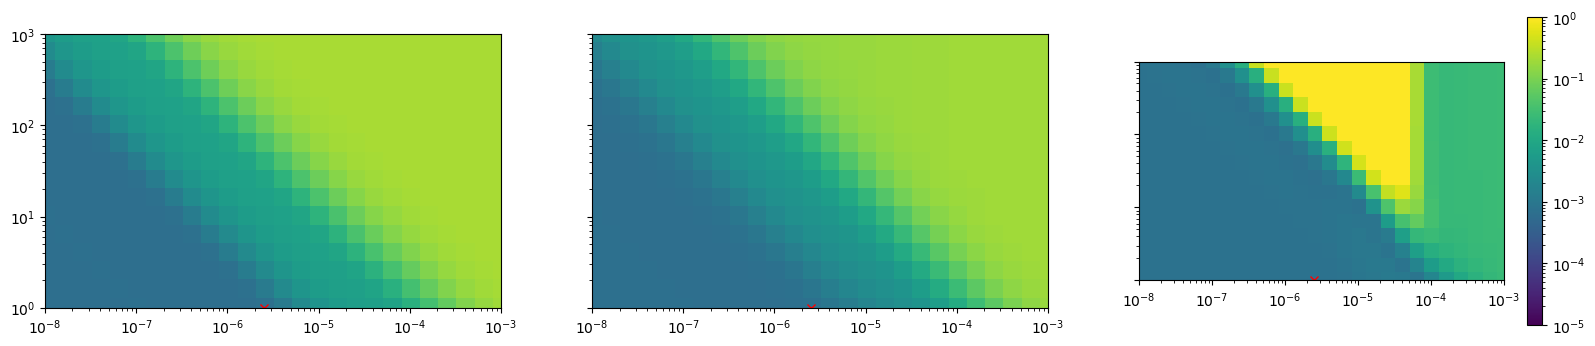

In [11]:
fig, axs = plt.subplots(1,n_para, sharex=True, sharey=True, figsize=(20, 4))

X, Y = np.meshgrid(weights_linear, ratio_cubic)

for i in range(n_para):
    cs = axs[i].pcolormesh(X, Y, training_error[:, :, i].T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(vmin=1e-5, vmax=1e+0)

    axs[i].plot([weights_linear[i_A_chosen]], [ratio_cubic[i_H_chosen]], marker = "x", color="r")

    axs[i].set_xscale("log")
    axs[i].set_yscale("log")
    axs[i].set_xlim(weights_linear[0], weights_linear[-1])
    axs[i].set_ylim(ratio_cubic[0], ratio_cubic[-1])
    axs[i].set_aspect("equal")
    
fig.colorbar(cs)

Choose one OpInf model and save the corresponding operator matrix

In [12]:
ROMq = np.zeros(nRB, dtype=object)
qInferred = np.zeros(nRB, dtype=object)
condition_no = np.zeros(nRB)

for n in range(nRB):

    if n_test > 1:
        # get data of the correct size
        D = matrixhandler.get_data_matrix(indices = [*range(n+1)])
        R = matrixhandler.get_rhs_matrix(indices = [*range(n+1)], indices_testspace = [*range(n+1)])

        # set up weights
        extension = np.hstack([weights_linear[i_A_chosen] * np.ones(n+1), weights_linear[i_A_chosen] * ratio_cubic[i_H_chosen] * np.ones(D.shape[1]-n-1)])

        # solve least squares problem
        inferred, condition_no[n] = regularized_least_squares(D, R, weights=extension, bool_collect_condition_numbers = True)

    # build corresponding ROM
    ROMq[n] = matrixhandler.get_reduced_model(A_new = inferred, 
                                                indices = [*range(n+1)], 
                                                indices_testspace = [*range(n+1)])
    qInferred[n] = inferred

Save it, to show that you have finally committed to it.

In [ ]:
# with open(savepath + f"trained_regularized/trained_regularized_n{nRB}", "wb") as file:
#     pickle.dump([qInferred, training_path, condition_no, training_time], file)

## Quick check-up

Load in the test data

In [ ]:
with open("/storage/nicole/git-save-data/opinf/cubic-heat/paper/data/trainingdata", "rb") as file:
    Xi_test, U_para_test, __ = pickle.load(file)
grid_t = np.arange(0, 1+0.001, 0.001)

Solve the ROM

In [15]:
# user input: choose which test parameter index to look at
i_test = 0

# initialization
U_test = U_para_test[i_test]
para_test = Xi_test[i_test, :]
names = ["regularized OpInf", "projection"]
errors = np.zeros((len(names), nRB, grid_t.shape[0]))

for n in range(nRB):

    # intrusive
    i = 0
    sol_RB = ROMq[n].solve_ivp(grid_t = grid_t, para = para_test)
    Sol_RB = ROMq[n].toFO(sol_RB)
    errors[i, n, :] = fom.norm_over_time(Sol_RB - U_test, axis = 0)

    # projection
    i = 1
    if transformer is None:
        proj = VR[:, :n+1].T @ fom.M @ U_test
    else:
        proj = VR[:, :n+1].T @ fom.M @ transformer.transform(U_test)
    Proj = ROMq[n].toFO(proj) 
    errors[i, n, :] = fom.norm_over_time(Proj - U_test, axis = 0)

NameError: name 'U_para_test' is not defined

Plot the error

TypeError: 'Axes' object is not subscriptable

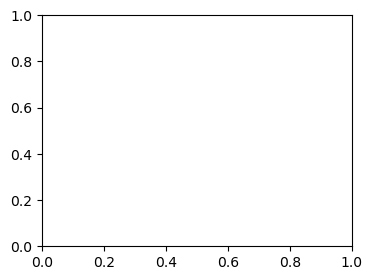

In [ ]:
fig, axs = plt.subplots(1, nRB, sharey = True, sharex = True, figsize = (4*nRB, 3))

for j in range(nRB):
    axs[j].semilogy([final_training_time, final_training_time], [1e-12, 1e+12])

    axs[j].semilogy(grid_t[::10], errors[0, j, ::10], label = names[0])
    axs[j].semilogy(grid_t[::10], errors[1, j, ::10], label = names[1], linestyle = "--")

    axs[j].legend()
    axs[j].set_xlabel("time")
    axs[j].set_title("r = {}".format(j + 1))
    axs[j].grid(True)

axs[0].set_ylim((1e-6, 1e+0))
axs[0].set_xlim((0-0.05, 1 + 0.05))

## The end.

In [ ]:
time_notebook = time.time() - tStart_notebook
print(f"Runtime of this notebook: {time_notebook / 60} min")

Runtime of this notebook: 0.20497109492619833 min
